# Q1

In this question, we will train a simple energy-based model (EBM) on the MNIST digit dataset.

Amir Kooshan Fattah Hesari - 401102191

## Setup

In [26]:
# Import necessary libraries
import random
import numpy as np
from tqdm import trange
from matplotlib import pyplot as plt

import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.nn.utils import spectral_norm
from torchvision import transforms,datasets
from torchvision.datasets import MNIST
import torchvision
from IPython.display import clear_output

In [2]:
# Get cpu, gpu or mps device for training.
device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu")
print(f"Using {device} device")

Using cuda device


# Dataset (10 points)

Load the `MNIST` dataset and normalize the images between -1 and 1 as this makes the implementation easier.

In [28]:
# TODO: Define transformations and set the batch size
transform = transforms.Compose([
    transforms.Resize((16,16)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

batch_size = 128

# TODO: Load train and test datasets
trainset = MNIST(root='./data', train=True, download=True, transform=transform)
testset = MNIST(root='./data', train=False, download=True, transform=transform)

# TODO: Load the train and test loaders
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False)

# Langevin Dynamics (20 points)

The Langevin dynamics in our case starts with a randomly initialized $x_0$ and then uses the information about the landscape of the energy function
(i.e., the gradient) to seek for new $x$, that is:
$$x_{t+1} = x_{t} + \alpha \nabla_{x_t}\text{LogSumExp} \left[f_{\theta} (x) \right] + \sigma \cdot \epsilon$$

where $\alpha, \sigma > 0$ and $\epsilon \sim \mathcal{N}(0, I)$. The Langevin dynamics could be seen as the stochastic gradient descent in the observable space with a small Gaussian noise added at each step.

Our goal is to run the Langevin dynamics for $\eta$ iterations with the steps size $\alpha$ and the noise level equal $\sigma$.

In [29]:
import torch

def energy_gradient(model, x):
    """
    Returns grad_E(x) where E(x) = -logsumexp(f_theta(x)).
    So grad_E(x) = - d/dx logsumexp(f_theta(x)).

    Notes:
    - Uses .mean() (not .sum()) so gradient scale doesn't blow up with batch size.
    - Restores model train/eval state.
    - Works even if called under torch.no_grad() via torch.enable_grad().
    """
    with torch.enable_grad():
        was_training = model.training
        model.eval()

        x_in = x.detach().clone().requires_grad_(True)

        logits = model(x_in)                          # [B, C]
        lse = torch.logsumexp(logits, dim=1).sum()   # scalar (stable scaling)

        grad_lse, = torch.autograd.grad(
            outputs=lse,
            inputs=x_in,
            create_graph=False,
            retain_graph=False,
            only_inputs=True
        )

        if was_training:
            model.train()

        # grad_E = -grad_lse because E = -lse
        return (grad_lse).detach()

In [30]:
def langevin_dynamics_step(model, x, alpha, sigma):
    # TODO: Calculate gradient w.r.t. x
    grad = energy_gradient(model, x)

    # TODO: Sample epsilon ~ Normal(0, I)
    epsilon = torch.randn_like(x)

    # TODO: Generatae a new sample
    x_new = x + alpha * grad + sigma * epsilon

    # TODO: Return the new sample
    return x_new

# Sampling (15 points)

In [31]:
def sample(model, eta, alpha, sigma):
    # determine the device based on the model parameters
    device = next(model.parameters()).device
    
    # todo: sample x0 from uniform [-1, +1]
    x = torch.rand((batch_size, 1, 16, 16), device=device) * 2 - 1

    # todo: run langevin dynamics η times
    for _ in range(eta):
        x = langevin_dynamics_step(model, x, alpha, sigma)
        x = torch.clamp(x, -1, 1) 

    # todo: return the result
    return x

# Loss (15 points)

We can evaluate our model using the following objective:

$$\mathcal{L} = \mathcal{L}_\text{clf}(\theta) + \mathcal{L}_\text{gen}(\theta)$$

Where $\mathcal{L}_\text{clf}(\theta)$ is the cross-entropy loss and $\mathcal{L}_\text{gen}(\theta)$ is an approximation to the log-marginal distribution over images (for example the LogSumExp loss).

In [32]:
def loss_function(model, eta, alpha, sigma, x, y_pred, y_true):
    # TODO: Calculate the discriminative loss: the cross-entropy
    # y_pred: logits [B, C], y_true: labels [B]
    L_clf = F.cross_entropy(y_pred, y_true)
    logsumexp_real = torch.logsumexp(y_pred, dim=1)
    energy_data = -logsumexp_real.mean()
    # TODO: Calculate the generative loss: E(x) - E(x_sample)
    # Using E(x) = -LogSumExp(f_theta(x))
    # x_sample is drawn by Langevin dynamics from the model
    x_sample = sample(model, eta=eta, alpha=alpha, sigma=sigma)
    logits_sample = model(x_sample.detach())
    logsumexp_sample = torch.logsumexp(logits_sample, dim=1)
    energy_sample = -logsumexp_sample.mean()
    
    logits_data = model(x)              # [B, C]
    logits_sample = model(x_sample)     # [B, C]

    E_data = -torch.logsumexp(logits_data, dim=1).mean()
    E_sample = -torch.logsumexp(logits_sample, dim=1).mean()

    L_gen = E_data - E_sample

    # 3. Regularization
    # Penalize the magnitude of the energies so they don't explode
    reg_loss = 0.07 * ( (energy_data**2) + (energy_sample**2) )

    # TODO: Return the total loss
    return L_clf + L_gen+ reg_loss


# Neural Network (10 points)

Define the neural network that specifies the energy function.
The inputs should be images and the outputs must be the classes.
Don't forget to use appropriate activation functions!

In [38]:
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm

class EnergyNet(nn.Module):
    def __init__(self, num_classes=10, negative_slope=0.2):
        super().__init__()
        self.negative_slope = negative_slope

        # (B,1,14,14)
        self.conv1 = spectral_norm(nn.Conv2d(1, 32, kernel_size=3, padding=1))
        self.gn1   = nn.GroupNorm(8, 32)

        # downsample with stride instead of maxpool: -> (B,64,7,7)
        self.conv2 = spectral_norm(nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=2))
        self.gn2   = nn.GroupNorm(8, 64)

        self.fc1   = spectral_norm(nn.Linear(64 * 7 * 7, 128))
        self.gn3   = nn.GroupNorm(8, 128)

        self.fc2   = spectral_norm(nn.Linear(128, num_classes))

    def forward(self, x, y=None):
        h = self.conv1(x)
        h = self.gn1(h)
        h = F.silu(h)

        h = self.conv2(h)
        h = self.gn2(h)
        h = F.silu(h)

        h = h.view(h.size(0), -1)

        h = self.fc1(h)
        h = self.gn3(h.unsqueeze(-1)).squeeze(-1)  # GroupNorm expects (N,C,*) so add dummy dim
        h = F.silu(h)

        logits = self.fc2(h)

        if y is not None:
            return logits.gather(1, y.view(-1, 1)).squeeze(1)
        return logits


# Visualize (15 points)

Create the following functions to be able to visualize real and generated images.

In [34]:
def visualize_real(loader):
    data_iter = iter(loader)
    images, labels = next(data_iter)
    images = images[:32]
    images = images * 0.5 + 0.5
    grid = torchvision.utils.make_grid(images, nrow=8)

    np_img = grid.permute(1, 2, 0).numpy()
    
    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.title("Real Images")
    plt.axis("off")
    plt.show()

def visualize_generated(model, eta, alpha, sigma, loader):
    device = next(model.parameters()).device
    model.eval()
    fake_images = sample(model, eta, alpha, sigma)
    
    fake_images = fake_images[:32].detach().cpu()
    fake_images = fake_images * 0.5 + 0.5
    fake_images = torch.clamp(fake_images, 0, 1)
    
    grid = torchvision.utils.make_grid(fake_images, nrow=8)
    
    np_img = grid.permute(1, 2, 0).numpy()
    
    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.title(f"Generated Images (eta={eta})")
    plt.axis("off")
    plt.show()

# Training (15 points)

Fill in the evaluation and training functions. Make sure you track the loss and plot it to analyze possible issues.

In [35]:
import torch
import torch.nn.functional as F
import math
def eval_ebm(model, loader, eta, alpha, sigma):
    device = next(model.parameters()).device
    model.eval()

    total_loss, total_acc, total_n = 0.0, 0.0, 0

    # regularizer (parameter L2)
    lambda_l2 = 1e-5

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            bs = x.size(0)

            y_pred = model(x)

            # predefined loss
            loss = loss_function(model, eta, alpha, sigma, x, y_pred, y)
            acc = (y_pred.argmax(dim=1) == y).float().mean()

            total_loss += loss.item() * bs
            total_acc += acc.item() * bs
            total_n += bs

    return {
        "loss": total_loss / max(total_n, 1),
        "acc":  total_acc / max(total_n, 1),
    }


def train_ebm(model, optimizer, loader, epochs, eta, alpha, sigma):
    device = next(model.parameters()).device

    # set learning rate to 1e-4
    for pg in optimizer.param_groups:
        pg["lr"] = 1e-4
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, total_acc, total_n = 0.0, 0.0, 0
        log_every = max(1, len(loader) // 5)
        for i, (x, y) in enumerate(loader, start=1):
            x, y = x.to(device), y.to(device)
            bs = x.size(0)

            y_pred = model(x)

            # predefined loss
            loss = loss_function(model, eta, alpha, sigma, x, y_pred, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            acc = (y_pred.argmax(dim=1) == y).float().mean()
            total_loss += loss.item() * bs
            total_acc += acc.item() * bs
            total_n += bs
            if (i % log_every == 0) or (i == 1) or (i == len(loader)):
                print(
                    f"Epoch [{epoch}/{epochs}] Step [{i}/{len(loader)}] "
                    f"loss={loss.item():.4f} acc={acc.item():.4f}"
                )

        epoch_stats = {
            "epoch": epoch,
            "loss": total_loss / max(total_n, 1),
            "acc":  total_acc / max(total_n, 1),
        }
        history.append(epoch_stats)

        print(f"==> Epoch {epoch} done: loss={epoch_stats['loss']:.4f} acc={epoch_stats['acc']:.4f}")

    return history


Now define the optimizer and train your model.

In [39]:
ebm_model = EnergyNet().to(device)
print("fc:", ebm_model.fc)
print("fc.in_features:", ebm_model.fc.in_features)

fc: Linear(in_features=256, out_features=10, bias=True)
fc.in_features: 256


epoch: 20
epoch [1/20] and loss: 2.3760
epoch [2/20] and loss: 1.4985
epoch [3/20] and loss: 1.2558
epoch [4/20] and loss: 1.1256
epoch [5/20] and loss: 1.0225
epoch :5


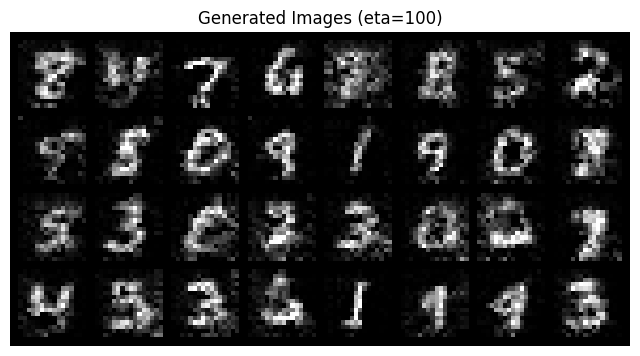

epoch [6/20] and loss: 0.9301
epoch [7/20] and loss: 0.8400
epoch [8/20] and loss: 0.7507
epoch [9/20] and loss: 0.6144
epoch [10/20] and loss: -0.1693
epoch :10


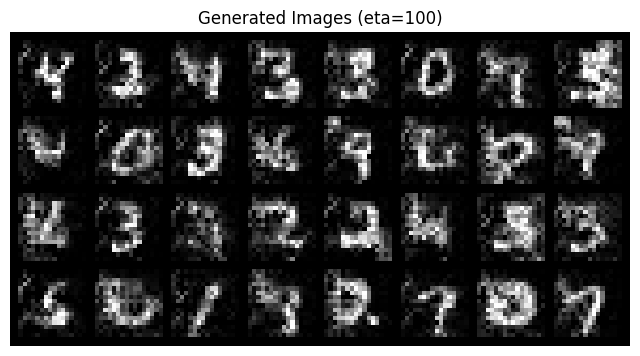

epoch [11/20] and loss: -2.8774
epoch [12/20] and loss: -3.3985
epoch [13/20] and loss: -3.8658
epoch [14/20] and loss: -4.2569
epoch [15/20] and loss: -4.5149
epoch :15


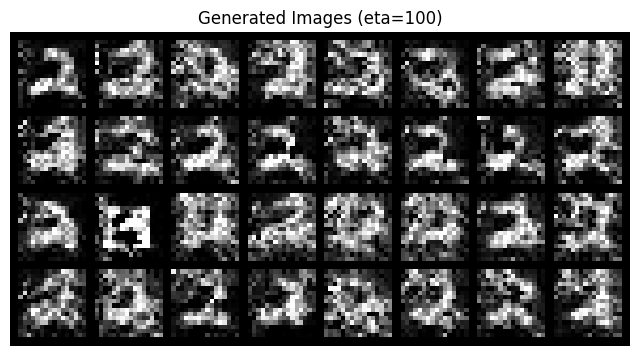

epoch [16/20] and loss: -4.6407
epoch [17/20] and loss: -4.6923
epoch [18/20] and loss: -4.7189
epoch [19/20] and loss: -4.7376
epoch [20/20] and loss: -4.7516
epoch :20


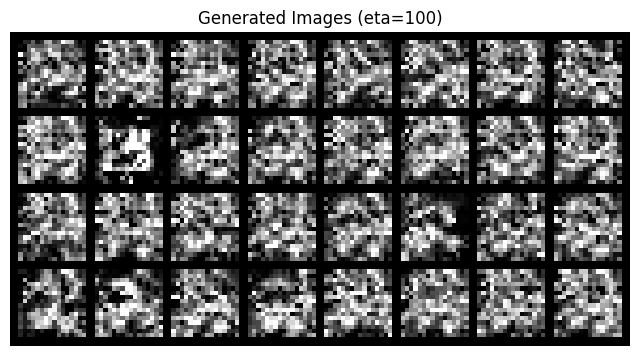

In [40]:
# TODO: Train your EBM
eta = 100       
alpha = 1.0     
sigma = 0.01    
epochs = 20     
lr = 1e-4       
ebm_model = EnergyNet().to(device)
optimizer = optim.Adam(ebm_model.parameters(), lr=lr)

loss_history = train_ebm(ebm_model, optimizer, trainloader, epochs, eta, alpha, sigma)


Plot the training curve.

Curve for the first 10 epochs

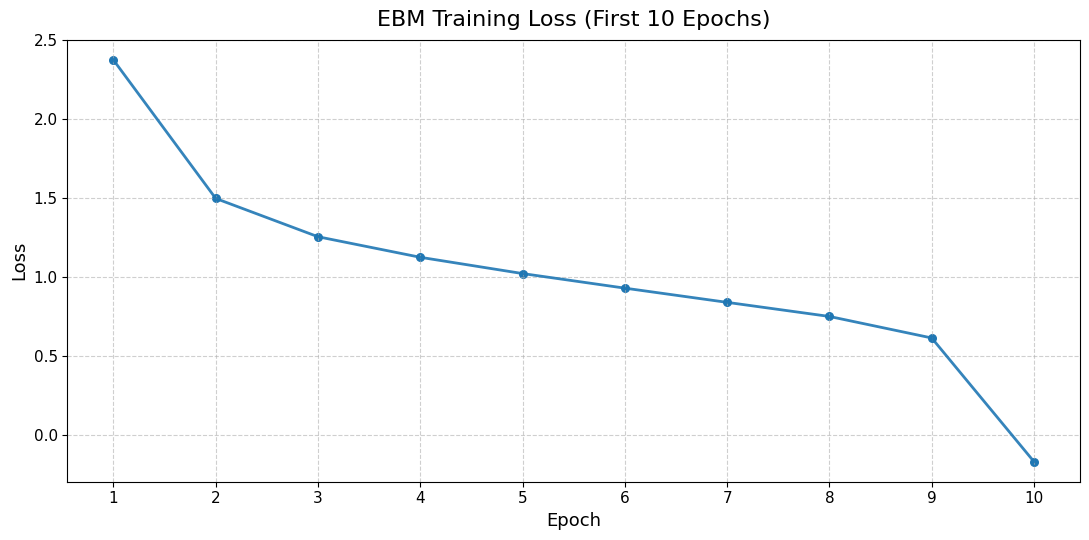

In [49]:
# Plot loss for the first 10 epochs (cleaner look)
n = min(10, len(loss_history))
epochs = range(1, n + 1)
losses = loss_history[:n]

plt.figure(figsize=(11, 5.5))
plt.plot(epochs, losses, linewidth=2, alpha=0.9)
plt.scatter(epochs, losses, s=30)

plt.title("EBM Training Loss (First 10 Epochs)", fontsize=16, pad=10)
plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Loss", fontsize=13)

plt.xticks(list(epochs))
plt.tick_params(axis="both", labelsize=11)
plt.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.show()


Now visualize generated samples. (You can visualize images every few epochs to see the evolution of your network)

🔍 Loading checkpoints: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] — generating 8 samples each...
  ✅ Epoch 1 — samples generated successfully.
  ✅ Epoch 2 — samples generated successfully.
  ✅ Epoch 3 — samples generated successfully.
  ✅ Epoch 4 — samples generated successfully.
  ✅ Epoch 5 — samples generated successfully.
  ✅ Epoch 6 — samples generated successfully.
  ✅ Epoch 7 — samples generated successfully.
  ✅ Epoch 8 — samples generated successfully.
  ✅ Epoch 9 — samples generated successfully.
  ✅ Epoch 10 — samples generated successfully.


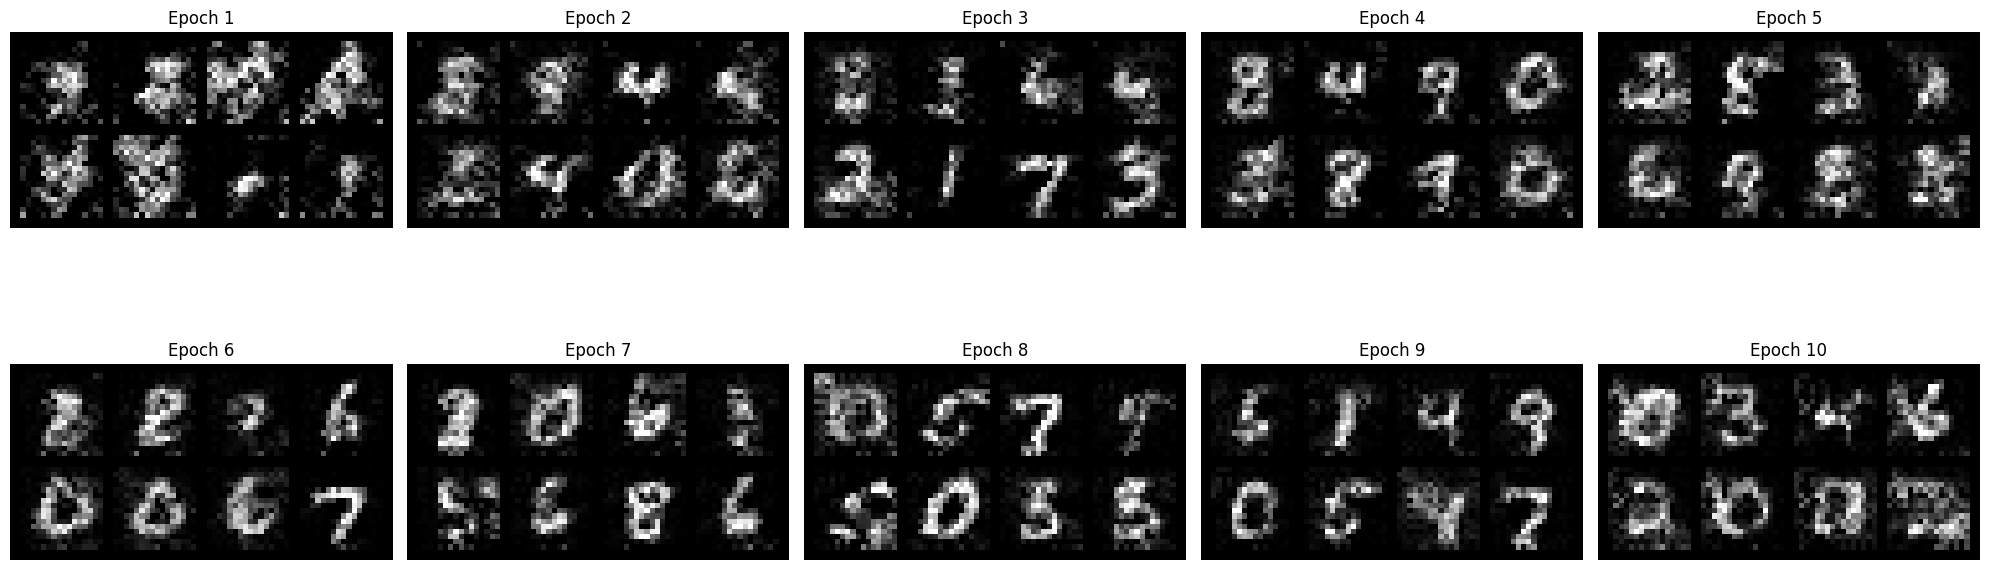

In [42]:
def visualize_checkpoints(epochs_list, eta, alpha, sigma, num_samples=8):
    # Set up a 2x5 grid of subplots to display checkpoint samples
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()

    # Use GPU if available, otherwise fall back to CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = EnergyNet().to(device)   # <-- make sure EnergyNet exists

    global batch_size
    original_bs = batch_size
    batch_size = num_samples  # Temporarily override batch size for sampling

    print(f"🔍 Loading checkpoints: {list(epochs_list)} — generating {num_samples} samples each...")

    for i, epoch_num in enumerate(epochs_list):
        if i >= len(axes):
            break

        filename = f"ebm_epoch_{epoch_num}.pth"
        try:
            # Load saved weights from checkpoint file
            model.load_state_dict(torch.load(filename, map_location=device))
            model.eval()

            # Generate samples using Langevin dynamics
            samples = sample(model, eta, alpha, sigma)  # <-- make sure sample(...) exists
            samples = samples.detach().cpu()

            # Denormalize from [-1, 1] to [0, 1] for display
            samples = samples * 0.5 + 0.5
            samples = torch.clamp(samples, 0, 1)

            # Build image grid and render on the corresponding subplot
            grid = torchvision.utils.make_grid(samples, nrow=4, padding=2)
            np_img = grid.permute(1, 2, 0).numpy()
            axes[i].imshow(np_img)
            axes[i].set_title(f"Epoch {epoch_num}")
            axes[i].axis("off")

            print(f"  ✅ Epoch {epoch_num} — samples generated successfully.")

        except FileNotFoundError:
            print(f"  ⚠️  Checkpoint not found: '{filename}' — skipping.")
        except Exception as e:
            print(f"  ❌ Failed to process epoch {epoch_num}: {e}")

    # Restore the original batch size after sampling
    batch_size = original_bs

    plt.tight_layout()
    plt.show()


# Visualize model snapshots from epoch 1 through 10
epochs_to_check = range(1, 11)
visualize_checkpoints(epochs_to_check, eta=100, alpha=1.0, sigma=0.01, num_samples=8)

If your resutls aren't great you can tune the hyperparameters to get better results or alternatively you can modify the dataset (resize, ...)to make it easier to learn the energy function.

epoch 11 and over that mark a turning point: the training loss plunges to very large negative values, indicating that the energy separation between the data manifold and noise has become overly aggressive, which destabilizes Langevin sampling and results in the collapse and noisy samples seen.

I also used resizing to 16x16 images.
